# 🗺️ Land Cover & Elevation
**ESIIL STARS 2026 · SICK**

**Prerequisites:** Complete Notebooks 1 and 2 first.

In this notebook you will:
1. Explore NLCD land cover classification for CSU campus
2. Detect land cover change between 2001 and 2021
3. Load the 3DEP digital elevation model
4. Combine land cover and elevation — a preview of the full Front Range analysis

**⏱ Estimated time:** 40–55 minutes

⚠️ **Branch check** — before running any cells, confirm you are on **your own branch**, not `main`.
In VS Code, open the **Source Control** panel (branch icon in the left sidebar).

1. Look at the current branch name in the Source Control view or status bar."
2. If you are on `main`, click the branch name in the status bar."
3. Choose **Create new branch...** and name it `yourname`."
4. Make sure that new branch is now selected before running notebook cells."

---
## Setup

In [1]:
# ── Standard imports ─────────────────────────────────────────────────
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

# ── GEE display helper ────────────────────────────────────────────────
def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
# ⚠️ Replace with YOUR project ID (same one from Notebook 1)
PROJECT_ID = 'ee-xs8091'

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine ready — project: {PROJECT_ID}")

✅ Earth Engine ready — project: ee-xs8091


In [3]:
# ── Study area: CSU campus ────────────────────────────────────────────
csu_lon, csu_lat = -105.0844, 40.5734
csu_aoi = ee.Geometry.Point([csu_lon, csu_lat]).buffer(1000).bounds()

# ── Landsat scale-factor helper ───────────────────────────────────────
def apply_scale_factors(image):
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    thermal = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return image.addBands(optical, overwrite=True) \
                .addBands(thermal, overwrite=True)

# ── Thumbnail helper (for saving static figures) ──────────────────────
def get_ee_thumbnail(image, vis_params, region, size=512):
    """Fetch a GEE image as a PIL Image for matplotlib/savefig."""
    params = {**vis_params, 'region': region.getInfo(),
              'dimensions': size, 'format': 'png'}
    url = image.getThumbURL(params)
    return Image.open(BytesIO(requests.get(url).content))

print("✅ Study area and helpers defined!")

✅ Study area and helpers defined!


---
## Part 5: Land Cover with NLCD

### What is NLCD?

The **National Land Cover Database (NLCD)** classifies every 30 m pixel across the contiguous US into standardized land cover categories — updated roughly every two years from 1985 to 2023. In GEE it's available as an `ee.ImageCollection` where each image is one year.

For our Front Range project, NLCD is the primary dataset: we'll measure how the area of forest, developed land, and grassland pixels changes with elevation over 39 years. This notebook introduces you to the dataset at campus scale first.

In [4]:
# Load NLCD for two years
nlcd_2001 = (ee.ImageCollection('USGS/NLCD_RELEASES/2019_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2001'))
             .first().select('landcover').clip(csu_aoi))

nlcd_2021 = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
             .filter(ee.Filter.eq('system:index', '2021'))
             .first().select('landcover').clip(csu_aoi))

# GEE knows NLCD's color palette — no vis_params needed
Map5 = geemap.Map(center=[csu_lat, csu_lon], zoom=14)
Map5.addLayer(nlcd_2001, {}, 'NLCD 2001')
Map5.addLayer(nlcd_2021, {}, 'NLCD 2021')
Map5.add_legend(title='NLCD Land Cover', builtin_legend='NLCD')
show_map(Map5)

Map(center=[40.5734, -105.0844], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### NLCD class codes — the ones you'll see most in Colorado

| Code | Class | Typical color |
|------|-------|--------------|
| 21–24 | Developed (Open → High intensity) | Pink → Dark red |
| 41 | Deciduous Forest | Light green |
| 42 | Evergreen Forest | Dark green |
| 52 | Shrub/Scrub | Tan |
| 71 | Grassland/Herbaceous | Yellow-green |
| 81 | Pasture/Hay | Yellow |
| 82 | Cultivated Crops | Brown |

Toggle between 2001 and 2021 on the map. Can you see development expanding around campus?

### Count pixels per class

`reduceRegion()` with `frequencyHistogram()` is a GEE reducer that counts how many pixels of each integer value fall inside your AOI. This is the exact approach we'll use at the Front Range scale.

In [5]:
def count_classes(nlcd_image, year):
    """Return a dict of {class_code: pixel_count} for an NLCD image."""
    result = nlcd_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=csu_aoi, scale=30, maxPixels=1e9
    ).getInfo()
    counts = result['landcover']
    print(f"\n--- NLCD {year} (top classes) ---")
    for code, n in sorted(counts.items(), key=lambda x: -x[1])[:8]:
        print(f"  Class {code}: {n:,} pixels")
    return counts

counts_2001 = count_classes(nlcd_2001, 2001)
counts_2021 = count_classes(nlcd_2021, 2021)


--- NLCD 2001 (top classes) ---
  Class 22: 1,969.7647058823527 pixels
  Class 23: 1,125.7686274509804 pixels
  Class 21: 845.4274509803919 pixels
  Class 24: 484.00784313725495 pixels

--- NLCD 2021 (top classes) ---
  Class 22: 1,806.2666666666664 pixels
  Class 23: 1,337.5058823529412 pixels
  Class 21: 658.3490196078429 pixels
  Class 24: 622.8470588235296 pixels


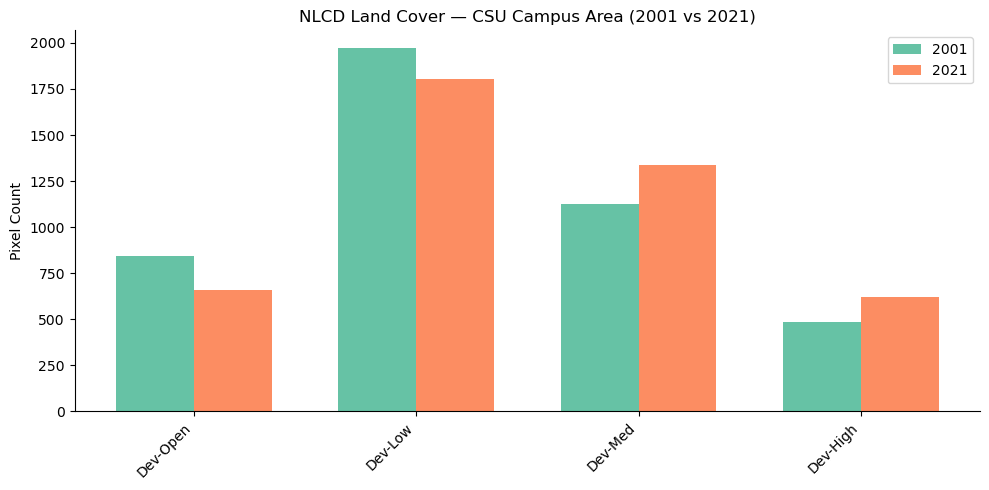

✅ Saved → figures/csu_nlcd_comparison.png


In [6]:
# Bar chart: 2001 vs 2021 side by side
nlcd_names = {
    '11':'Water','21':'Dev-Open','22':'Dev-Low','23':'Dev-Med','24':'Dev-High',
    '41':'Deciduous','42':'Evergreen','52':'Shrub','71':'Grassland',
    '81':'Pasture','82':'Crops'
}
all_classes = sorted(set(counts_2001) | set(counts_2021))
df = pd.DataFrame({
    'Class': [nlcd_names.get(c, f'Other ({c})') for c in all_classes],
    '2001':  [counts_2001.get(c, 0) for c in all_classes],
    '2021':  [counts_2021.get(c, 0) for c in all_classes],
})

fig, ax = plt.subplots(figsize=(10, 5))
x, w = range(len(df)), 0.35
ax.bar([i - w/2 for i in x], df['2001'], w, label='2001', color='#66c2a5')
ax.bar([i + w/2 for i in x], df['2021'], w, label='2021', color='#fc8d62')
ax.set_xticks(x); ax.set_xticklabels(df['Class'], rotation=45, ha='right')
ax.set_ylabel('Pixel Count')
ax.set_title('NLCD Land Cover — CSU Campus Area (2001 vs 2021)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/csu_nlcd_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_nlcd_comparison.png")

### 🏋️ Exercise 3

**3a.** Expand the AOI to a **5 km buffer** and re-run the class counts. Do you see more agricultural land?
```python
csu_wide = ee.Geometry.Point([csu_lon, csu_lat]).buffer(5000).bounds()
```

**3b.** Which class **increased** the most between 2001 and 2021? Which **decreased** the most?
Add a code cell that computes and prints the answer (don't just eyeball the chart).

In [7]:
# ✏️ Exercise 3a — 5 km AOI class counts
csu_wide = ee.Geometry.Point([csu_lon, csu_lat]).buffer(5000).bounds()

def count_classes_in_geom(nlcd_image, year, geom, top_n=10):
    """Count NLCD land-cover pixels within a provided geometry."""
    result = nlcd_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geom, scale=30, maxPixels=1e9
    ).getInfo()
    counts = result['landcover']

    print(f"\n--- NLCD {year} (5 km AOI, top classes) ---")
    for code, n in sorted(counts.items(), key=lambda x: -x[1])[:top_n]:
        name = nlcd_names.get(code, f'Other ({code})')
        print(f"  Class {code} ({name}): {n:,} pixels")
    return counts

counts_wide_2001 = count_classes_in_geom(nlcd_2001, 2001, csu_wide)
counts_wide_2021 = count_classes_in_geom(nlcd_2021, 2021, csu_wide)

ag_2001 = counts_wide_2001.get('81', 0) + counts_wide_2001.get('82', 0)
ag_2021 = counts_wide_2021.get('81', 0) + counts_wide_2021.get('82', 0)
print(f"\nAgriculture (Pasture + Crops) in 2001: {ag_2001:,} pixels")
print(f"Agriculture (Pasture + Crops) in 2021: {ag_2021:,} pixels")


--- NLCD 2001 (5 km AOI, top classes) ---
  Class 22 (Dev-Low): 1,969.7647058823527 pixels
  Class 23 (Dev-Med): 1,125.7686274509804 pixels
  Class 21 (Dev-Open): 845.4274509803919 pixels
  Class 24 (Dev-High): 484.00784313725495 pixels

--- NLCD 2021 (5 km AOI, top classes) ---
  Class 22 (Dev-Low): 1,806.2666666666664 pixels
  Class 23 (Dev-Med): 1,337.5058823529412 pixels
  Class 21 (Dev-Open): 658.3490196078429 pixels
  Class 24 (Dev-High): 622.8470588235296 pixels

Agriculture (Pasture + Crops) in 2001: 0 pixels
Agriculture (Pasture + Crops) in 2021: 0 pixels


In [8]:
# ✏️ Exercise 3b — largest increase and decrease
all_codes = sorted(set(counts_2001) | set(counts_2021))

change_rows = []
for code in all_codes:
    c2001 = counts_2001.get(code, 0)
    c2021 = counts_2021.get(code, 0)
    delta = c2021 - c2001
    change_rows.append((code, nlcd_names.get(code, f'Other ({code})'), c2001, c2021, delta))

change_df = pd.DataFrame(change_rows, columns=['Code', 'Class', '2001', '2021', 'Change'])
change_df = change_df.sort_values('Change', ascending=False)

most_increase = change_df.iloc[0]
most_decrease = change_df.iloc[-1]

print('Class changes (2021 - 2001), sorted:')
display(change_df[['Code', 'Class', 'Change']])

print(f"\nMost increased: Class {most_increase['Code']} ({most_increase['Class']}) with {int(most_increase['Change']):,} pixels")
print(f"Most decreased: Class {most_decrease['Code']} ({most_decrease['Class']}) with {int(most_decrease['Change']):,} pixels")

Class changes (2021 - 2001), sorted:


,Code,Class,Change
2,23,Dev-Med,211.737255
3,24,Dev-High,138.839216
1,22,Dev-Low,-163.498039
0,21,Dev-Open,-187.078431



Most increased: Class 23 (Dev-Med) with 211 pixels
Most decreased: Class 21 (Dev-Open) with -187 pixels


---
## Part 6: Elevation with the USGS 3DEP DEM

### What is a DEM?

A **Digital Elevation Model (DEM)** is a raster where every pixel value is the terrain elevation in metres above sea level. The USGS 3D Elevation Program (3DEP) provides a 10 m resolution DEM for the entire US, available in GEE at `'USGS/3DEP/10m'`.

For our project, elevation is the key structuring variable — we'll divide the Front Range into 100 m elevation bands and ask how forest cover in each band has changed over 39 years.

In [9]:
# Use a wider AOI to see the foothills rising west of campus
foothills_aoi = ee.Geometry.Point([csu_lon, csu_lat]).buffer(15000).bounds()

dem = ee.Image('USGS/3DEP/10m').clip(foothills_aoi)

elev_vis = {
    'min': 1500, 'max': 2200,
    'palette': ['#2b83ba', '#abdda4', '#ffffbf', '#fdae61', '#d7191c']
}

Map6 = geemap.Map(center=[csu_lat, csu_lon - 0.05], zoom=12)
Map6.addLayer(dem, elev_vis, 'Elevation (m)')
Map6.add_colorbar(elev_vis, label='Elevation (m)')
show_map(Map6)

Map(center=[40.5734, -105.1344], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### Derive slope from the DEM

In [10]:
slope = ee.Terrain.slope(dem)

slope_vis = {'min': 0, 'max': 30,
             'palette': ['#f7fcf5', '#74c476', '#238b45', '#00441b']}

Map7 = geemap.Map(center=[csu_lat, csu_lon - 0.05], zoom=12)
Map7.addLayer(slope, slope_vis, 'Slope (degrees)')
Map7.add_colorbar(slope_vis, label='Slope (degrees)')
show_map(Map7)

Map(center=[40.5734, -105.1344], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

---
## Part 7: Combining DEM + NLCD — A Preview of the Front Range Analysis

This is the core analytical move for our project. We'll sample points that have both an elevation value and a land cover class, then ask: **"How does land cover vary with elevation?"**

At the Front Range scale we'll do this across 39 years. Here we do it once for 2021 at campus scale.

In [11]:
# Load NLCD 2021 for the wider foothills AOI
nlcd_foothills = (ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')
                  .filter(ee.Filter.eq('system:index', '2021'))
                  .first().select('landcover').clip(foothills_aoi))

# Stack DEM + NLCD into a single multi-band image, then sample
combined = dem.addBands(nlcd_foothills)

samples = combined.sample(
    region=foothills_aoi, scale=30,
    numPixels=2000, seed=42, geometries=False
)

df_samples = geemap.ee_to_df(samples, remove_geom=False)
print(f"Sampled {len(df_samples)} points")
df_samples.head()

Sampled 2000 points


,geo,elevation,landcover
0,None,1649.561035,11
1,None,1686.332275,52
2,None,1509.971924,23
3,None,1530.871826,23
4,None,1536.269165,82


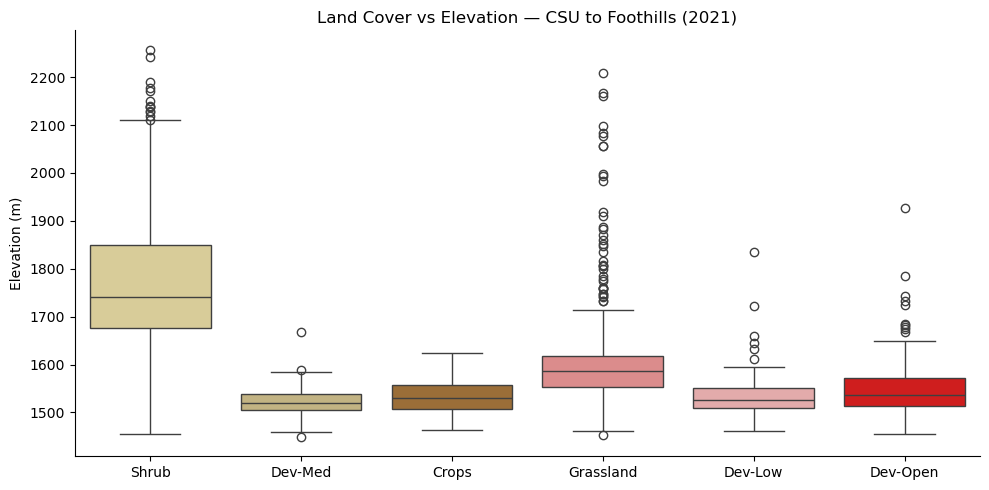

✅ Saved → figures/csu_landcover_vs_elevation.png


In [13]:
nlcd_name_map = {
    11:'Water', 21:'Dev-Open', 22:'Dev-Low', 23:'Dev-Med', 24:'Dev-High',
    41:'Deciduous', 42:'Evergreen', 43:'Mixed Forest',
    52:'Shrub', 71:'Grassland', 81:'Pasture', 82:'Crops', 90:'Wetland'
}
nlcd_color_map = {
    'Dev-Open':'#eda1a1','Dev-Low':'#e87f7f','Dev-Med':'#ed0000','Dev-High':'#ab0000',
    'Evergreen':'#1c6330','Deciduous':'#68ab63','Grassland':'#e3d28e',
    'Shrub':'#ccb879','Pasture':'#dbd93d','Crops':'#ab7028'
}

df_samples['Land Cover'] = df_samples['landcover'].map(nlcd_name_map)
df_samples = df_samples.dropna(subset=['Land Cover'])

top_classes = df_samples['Land Cover'].value_counts().head(6).index.tolist()
df_plot = df_samples[df_samples['Land Cover'].isin(top_classes)]
colors = [nlcd_color_map.get(c, '#999999') for c in top_classes]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_plot, x='Land Cover', y='elevation', palette=colors, ax=ax)
ax.set_ylabel('Elevation (m)'); ax.set_xlabel('')
ax.set_title('Land Cover vs Elevation — CSU to Foothills (2021)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/csu_landcover_vs_elevation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved → figures/csu_landcover_vs_elevation.png")

### 🏋️ Exercise 4

**4a.** Make an **elevation histogram** of the sampled points. What is the elevation range in the 15 km study area?
```python
plt.hist(df_samples['elevation'], bins=30, color='steelblue', edgecolor='white')
```

**4b.** Which land cover class sits at the **highest median elevation** in the boxplot? Does that make ecological sense given what you know about the Front Range? Write your answer as a markdown cell.

**4c. Stretch:** Re-do the boxplot but split by **slope** instead of land cover. Create a new column:
```python
# You'll need to sample slope the same way as elevation — add slope as a band in 'combined'
```
Does forest occur on steeper slopes than grassland?

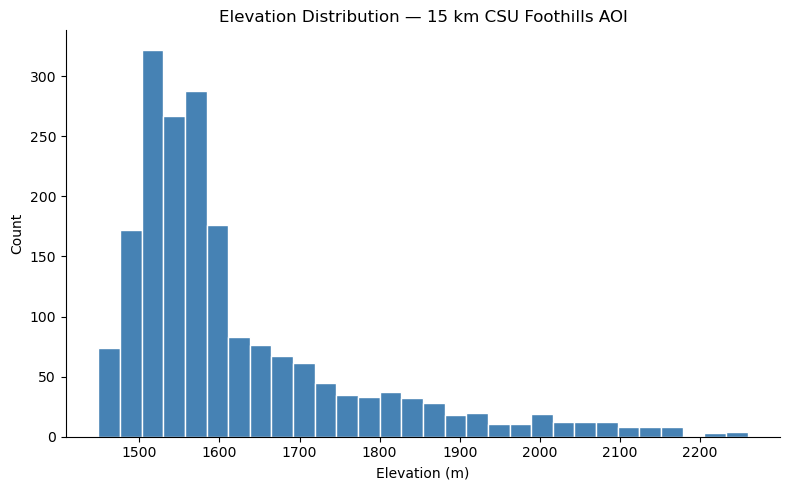

Elevation range: 1448.8 m to 2259.4 m


In [14]:
# ✏️ Exercise 4a — elevation histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_samples['elevation'], bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Count')
ax.set_title('Elevation Distribution — 15 km CSU Foothills AOI')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

elev_min = df_samples['elevation'].min()
elev_max = df_samples['elevation'].max()
print(f"Elevation range: {elev_min:.1f} m to {elev_max:.1f} m")

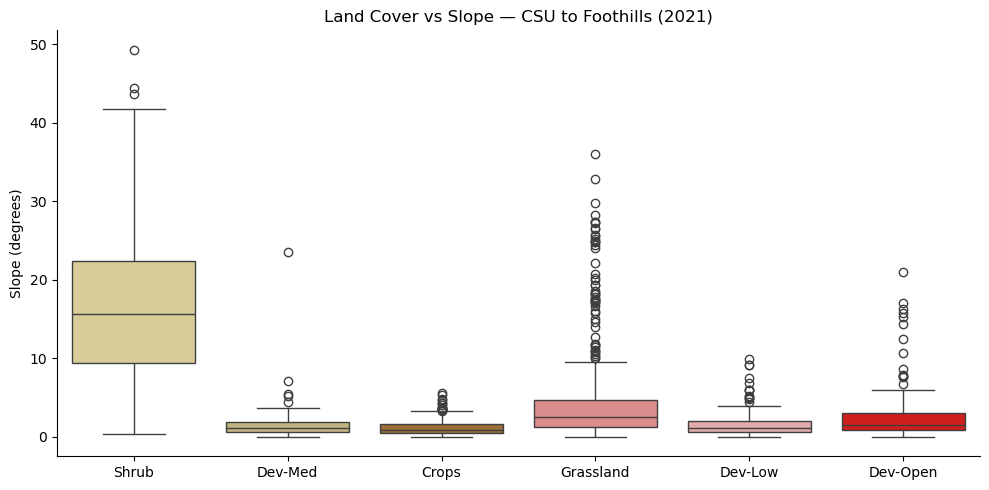

Median slope (forest classes): 19.49°
Median slope (grassland): 2.59°
Forest occurs on steeper slopes than grassland in this sample.


In [15]:
# ✏️ Exercise 4c — slope boxplot (stretch)
# Re-sample with slope included as an additional band
combined_slope = dem.addBands(slope).addBands(nlcd_foothills)

samples_slope = combined_slope.sample(
    region=foothills_aoi, scale=30,
    numPixels=2000, seed=42, geometries=False
)

df_slope = geemap.ee_to_df(samples_slope, remove_geom=False)
df_slope['Land Cover'] = df_slope['landcover'].map(nlcd_name_map)
df_slope = df_slope.dropna(subset=['Land Cover', 'slope'])

top_classes_slope = df_slope['Land Cover'].value_counts().head(6).index.tolist()
df_slope_plot = df_slope[df_slope['Land Cover'].isin(top_classes_slope)]
colors_slope = [nlcd_color_map.get(c, '#999999') for c in top_classes_slope]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_slope_plot, x='Land Cover', y='slope', palette=colors_slope, ax=ax)
ax.set_ylabel('Slope (degrees)'); ax.set_xlabel('')
ax.set_title('Land Cover vs Slope — CSU to Foothills (2021)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

forest_classes = ['Evergreen', 'Deciduous', 'Mixed Forest']
forest_mask = df_slope['Land Cover'].isin(forest_classes)
grass_mask = df_slope['Land Cover'] == 'Grassland'

forest_median = df_slope.loc[forest_mask, 'slope'].median()
grass_median = df_slope.loc[grass_mask, 'slope'].median()

print(f"Median slope (forest classes): {forest_median:.2f}°")
print(f"Median slope (grassland): {grass_median:.2f}°")
if pd.notna(forest_median) and pd.notna(grass_median):
    if forest_median > grass_median:
        print("Forest occurs on steeper slopes than grassland in this sample.")
    elif forest_median < grass_median:
        print("Grassland occurs on steeper slopes than forest in this sample.")
    else:
        print("Forest and grassland have the same median slope in this sample.")

---
## ✅ You're Done with the Tutorials!

Across the three notebooks you've learned:
- How GEE works, how to authenticate, and how to avoid common pitfalls
- How to load and visualize Landsat imagery (true color, false color)
- How to compute spectral indices (NDVI) and detect change
- How to work with NLCD land cover and count pixels per class
- How to load a DEM, compute slope, and combine it with land cover

These are the exact tools and patterns the Front Range project uses — just at a larger spatial scale and over a 39-year time series. You're ready to start on the analysis notebooks in `notebooks/`.

---
## 💾 Save Your Work

1. Click the **Source Control** icon (left sidebar) — it looks like a branching tree.
2. Stage all changed files with **+**.
3. Write a commit message, e.g. `"Complete notebook 2 NDVI exercises"`.
4. Click **Commit & Push**.

⚠️ Push to **your branch only**, not `main`.